<a href="https://colab.research.google.com/github/humairasundas220/DevelopersHub_AI_ML_Internship_Advaned_Tasks/blob/main/Telco_Churn_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 2: End-to-End ML Pipeline for Telco Customer Churn Prediction

## 1. Problem Statement & Objective

**Problem:** Telecom companies lose revenue when customers cancel ("churn") their subscriptions. Being able to flag customers who are likely to churn lets the business intervene early (offers, support outreach, retention plans) before they leave.

**Objective:** Build a **reusable, production-ready** machine learning pipeline that:
- Cleans and preprocesses the raw Telco Churn dataset (scaling numeric features, encoding categorical features) using scikit-learn's `Pipeline` / `ColumnTransformer` API, so preprocessing and modeling are bundled into a single object.
- Trains and compares two classifiers: **Logistic Regression** and **Random Forest**.
- Tunes each model's hyperparameters with **GridSearchCV** (cross-validated grid search).
- Evaluates both models with classification metrics (accuracy, precision, recall, F1, ROC-AUC) and visualizations.
- Exports the best full pipeline (preprocessing + model) with **joblib**, so it can be reloaded elsewhere and used directly on raw, unprocessed data — no separate preprocessing code required at inference time.

**Dataset:** [Telco Customer Churn dataset](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) (IBM sample dataset, ~7,043 customers, 21 columns: demographics, account info, services subscribed, and the `Churn` label).

In [1]:
# Core libraries
import os
import pandas as pd
import numpy as np

# Modeling
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay
)
import joblib

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Dataset Loading & Preprocessing

### 2.1 Loading the data

Download the dataset from Kaggle (`WA_Fn-UseC_-Telco-Customer-Churn.csv`) and place it in the same folder as this notebook.

To make this notebook runnable and testable even before the file is downloaded, `load_data()` below first looks for the real CSV in a few likely locations. **If it can't find the real file, it generates a synthetic dataset with the exact same column names/types** so every downstream cell (pipeline, GridSearchCV, evaluation, export) can still be demonstrated end-to-end.

> **Before final submission: download the real Kaggle CSV and place it next to this notebook** (or update `CANDIDATE_PATHS`) so the results reflect the real data, not the synthetic placeholder.

In [2]:
CANDIDATE_PATHS = [
    "WA_Fn-UseC_-Telco-Customer-Churn.csv",
    "Telco-Customer-Churn.csv",
]

def _generate_synthetic_telco(seed=RANDOM_STATE, n=2000):
    """Schema-matched stand-in for the real Telco dataset, used only if the
    real CSV isn't found, so the whole pipeline can still be executed."""
    rng = np.random.default_rng(seed)
    tenure = rng.integers(0, 73, n)
    contract = rng.choice(["Month-to-month", "One year", "Two year"], n, p=[0.55, 0.24, 0.21])
    internet_service = rng.choice(["DSL", "Fiber optic", "No"], n, p=[0.35, 0.44, 0.21])
    partner = rng.choice(["Yes", "No"], n)
    monthly_charges = np.round(rng.uniform(18, 120, n), 2)
    total_charges = np.round(monthly_charges * tenure + rng.normal(0, 20, n).clip(min=0), 2)

    churn_score = (-0.05 * tenure + (contract == "Month-to-month") * 1.2
                   + (internet_service == "Fiber optic") * 0.5 + 0.01 * monthly_charges
                   - (partner == "Yes") * 0.3 + rng.normal(0, 1, n))
    churn_prob = 1 / (1 + np.exp(-(churn_score - 1)))
    churn = np.where(rng.uniform(0, 1, n) < churn_prob, "Yes", "No")

    df = pd.DataFrame({
        "customerID": [f"CUST-{i:05d}" for i in range(n)],
        "gender": rng.choice(["Male", "Female"], n),
        "SeniorCitizen": rng.choice([0, 1], n, p=[0.84, 0.16]),
        "Partner": partner,
        "Dependents": rng.choice(["Yes", "No"], n),
        "tenure": tenure,
        "PhoneService": rng.choice(["Yes", "No"], n, p=[0.9, 0.1]),
        "MultipleLines": rng.choice(["Yes", "No", "No phone service"], n),
        "InternetService": internet_service,
        "OnlineSecurity": rng.choice(["Yes", "No", "No internet service"], n),
        "OnlineBackup": rng.choice(["Yes", "No", "No internet service"], n),
        "DeviceProtection": rng.choice(["Yes", "No", "No internet service"], n),
        "TechSupport": rng.choice(["Yes", "No", "No internet service"], n),
        "StreamingTV": rng.choice(["Yes", "No", "No internet service"], n),
        "StreamingMovies": rng.choice(["Yes", "No", "No internet service"], n),
        "Contract": contract,
        "PaperlessBilling": rng.choice(["Yes", "No"], n),
        "PaymentMethod": rng.choice(
            ["Electronic check", "Mailed check", "Bank transfer (automatic)", "Credit card (automatic)"], n),
        "MonthlyCharges": monthly_charges,
        "TotalCharges": total_charges.astype(str),
        "Churn": churn,
    })
    return df

def load_data():
    for path in CANDIDATE_PATHS:
        if os.path.exists(path):
            print(f"Loaded real dataset from: {path}")
            return pd.read_csv(path)
    print("Real Telco CSV not found in", CANDIDATE_PATHS,
          "-> using a schema-matched SYNTHETIC dataset instead.\n"
          "Download the real dataset from Kaggle and place it in this folder, then re-run, "
          "for the actual submission.")
    return _generate_synthetic_telco()

df = load_data()
df.head()

Real Telco CSV not found in ['WA_Fn-UseC_-Telco-Customer-Churn.csv', 'Telco-Customer-Churn.csv'] -> using a schema-matched SYNTHETIC dataset instead.
Download the real dataset from Kaggle and place it in this folder, then re-run, for the actual submission.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST-00000,Male,0,Yes,Yes,6,Yes,No phone service,No,No internet service,...,No internet service,Yes,No,No,Month-to-month,No,Electronic check,64.46,386.76,Yes
1,CUST-00001,Male,0,Yes,Yes,56,Yes,Yes,Fiber optic,Yes,...,No internet service,No internet service,No internet service,Yes,Month-to-month,Yes,Mailed check,30.12,1694.56,Yes
2,CUST-00002,Male,0,No,No,47,Yes,No,DSL,No internet service,...,No,No,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),76.06,3577.11,No
3,CUST-00003,Male,0,No,No,32,Yes,No,Fiber optic,No internet service,...,No internet service,Yes,Yes,Yes,Month-to-month,Yes,Mailed check,33.96,1094.26,No
4,CUST-00004,Male,0,Yes,No,31,Yes,No phone service,DSL,No internet service,...,Yes,No,No,No,One year,Yes,Bank transfer (automatic),24.22,760.25,No


In [3]:
print("Shape:", df.shape)
df.info()

Shape: (2000, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        2000 non-null   object 
 1   gender            2000 non-null   object 
 2   SeniorCitizen     2000 non-null   int64  
 3   Partner           2000 non-null   object 
 4   Dependents        2000 non-null   object 
 5   tenure            2000 non-null   int64  
 6   PhoneService      2000 non-null   object 
 7   MultipleLines     2000 non-null   object 
 8   InternetService   2000 non-null   object 
 9   OnlineSecurity    2000 non-null   object 
 10  OnlineBackup      2000 non-null   object 
 11  DeviceProtection  2000 non-null   object 
 12  TechSupport       2000 non-null   object 
 13  StreamingTV       2000 non-null   object 
 14  StreamingMovies   2000 non-null   object 
 15  Contract          2000 non-null   object 
 16  PaperlessBilling  2000 n

In [4]:
# Class balance -- churn is the target we're predicting
df["Churn"].value_counts(normalize=True).rename("proportion")

,proportion
Churn,
No,0.729
Yes,0.271


### 2.2 Cleaning

- `TotalCharges` is stored as text in the raw Kaggle file (a handful of new customers have blank values); convert to numeric and impute the small number of missing values.
- Drop `customerID` — it's a unique identifier, not a predictive feature.
- Encode the target `Churn` (`Yes`/`No`) as `1`/`0`.

In [5]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

df = df.drop(columns=["customerID"])
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

X = df.drop(columns=["Churn"])
y = df["Churn"]

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


### 2.3 Building the preprocessing pipeline

This is the core "production-ready" piece: instead of manually scaling/encoding the data and hoping we repeat the exact same steps at inference time, we wrap preprocessing in a `ColumnTransformer` and combine it with the model inside a single `Pipeline`. That whole object — preprocessing + model — is what gets trained, tuned, evaluated, and exported. Anyone who loads the exported file later can call `.predict()` directly on raw data, with no separate preprocessing code to keep in sync.

- **Numeric features** (`tenure`, `MonthlyCharges`, `TotalCharges`, `SeniorCitizen`): impute missing values with the median, then standardize with `StandardScaler` (important for Logistic Regression, harmless for Random Forest).
- **Categorical features** (contract type, internet service, payment method, etc.): impute missing values with the most frequent category, then one-hot encode with `handle_unknown="ignore"` so the pipeline won't break if it sees an unseen category in production data.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (1600, 19), Test shape: (400, 19)


## 3. Model Development & Training

We define two full pipelines (`preprocessor` + classifier) and tune each with `GridSearchCV` (5-fold cross-validation, optimizing ROC-AUC, which is more informative than accuracy on an imbalanced churn dataset).

In [7]:
log_reg_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=RANDOM_STATE)),
])

log_reg_params = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__solver": ["lbfgs", "liblinear"],
}

rf_params = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5],
}

log_reg_grid = GridSearchCV(log_reg_pipe, log_reg_params, cv=5, scoring="roc_auc", n_jobs=-1)
rf_grid = GridSearchCV(rf_pipe, rf_params, cv=5, scoring="roc_auc", n_jobs=-1)

In [8]:
print("Tuning Logistic Regression...")
log_reg_grid.fit(X_train, y_train)
print("Best LR params:", log_reg_grid.best_params_)
print("Best CV ROC-AUC:", log_reg_grid.best_score_)

Tuning Logistic Regression...
Best LR params: {'classifier__C': 0.1, 'classifier__solver': 'lbfgs'}
Best CV ROC-AUC: 0.7533285225504492


In [9]:
print("Tuning Random Forest...")
rf_grid.fit(X_train, y_train)
print("Best RF params:", rf_grid.best_params_)
print("Best CV ROC-AUC:", rf_grid.best_score_)

Tuning Random Forest...
Best RF params: {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Best CV ROC-AUC: 0.7519809709032943


## 4. Evaluation with relevant metrics

We evaluate both tuned models on the held-out test set using accuracy, precision, recall, F1, and ROC-AUC. For churn prediction, **recall** and **ROC-AUC** matter more than raw accuracy: missing an actual churner (false negative) is usually costlier than a false alarm, and the classes are imbalanced (~26-27% churn).

In [10]:
def evaluate(name, grid):
    preds = grid.predict(X_test)
    probs = grid.predict_proba(X_test)[:, 1]
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, probs),
    }
    print(f"--- {name} ---")
    print(classification_report(y_test, preds, target_names=["No Churn", "Churn"]))
    return metrics

results = [evaluate("Logistic Regression", log_reg_grid), evaluate("Random Forest", rf_grid)]
results_df = pd.DataFrame(results).set_index("Model")
results_df

--- Logistic Regression ---
              precision    recall  f1-score   support

    No Churn       0.79      0.89      0.84       292
       Churn       0.55      0.35      0.43       108

    accuracy                           0.75       400
   macro avg       0.67      0.62      0.63       400
weighted avg       0.72      0.75      0.73       400

--- Random Forest ---
              precision    recall  f1-score   support

    No Churn       0.80      0.91      0.85       292
       Churn       0.61      0.39      0.47       108

    accuracy                           0.77       400
   macro avg       0.70      0.65      0.66       400
weighted avg       0.75      0.77      0.75       400



,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.7475,0.550725,0.351852,0.429379,0.777048
Random Forest,0.7675,0.608696,0.388889,0.474576,0.778666


## 5. Visualizations

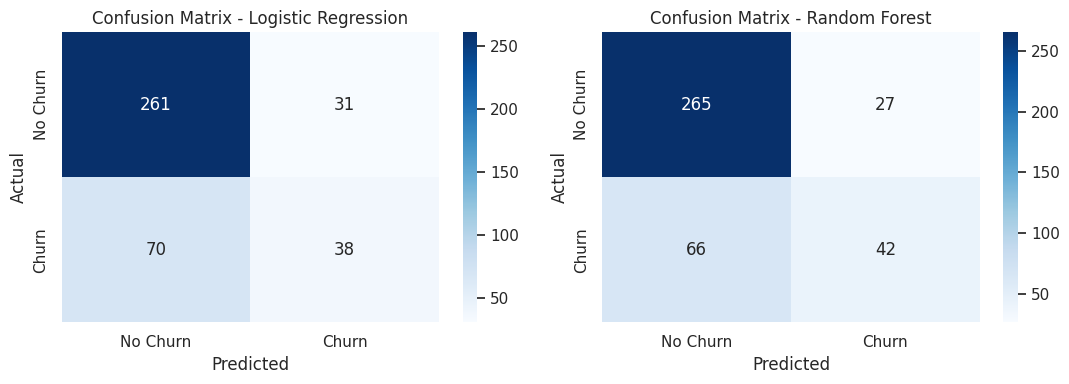

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, grid) in zip(axes, [("Logistic Regression", log_reg_grid), ("Random Forest", rf_grid)]):
    cm = confusion_matrix(y_test, grid.predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
    ax.set_title(f"Confusion Matrix - {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

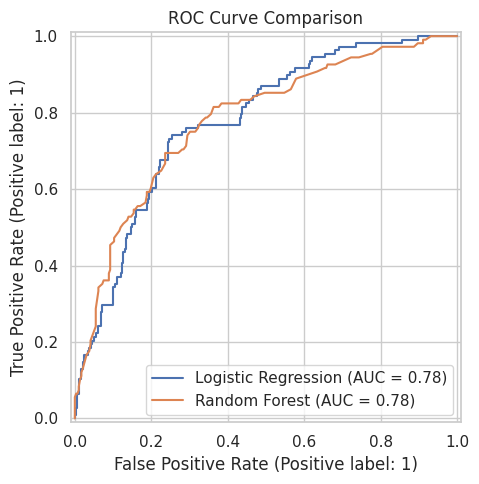

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(log_reg_grid, X_test, y_test, ax=ax, name="Logistic Regression")
RocCurveDisplay.from_estimator(rf_grid, X_test, y_test, ax=ax, name="Random Forest")
ax.set_title("ROC Curve Comparison")
plt.tight_layout()
plt.show()

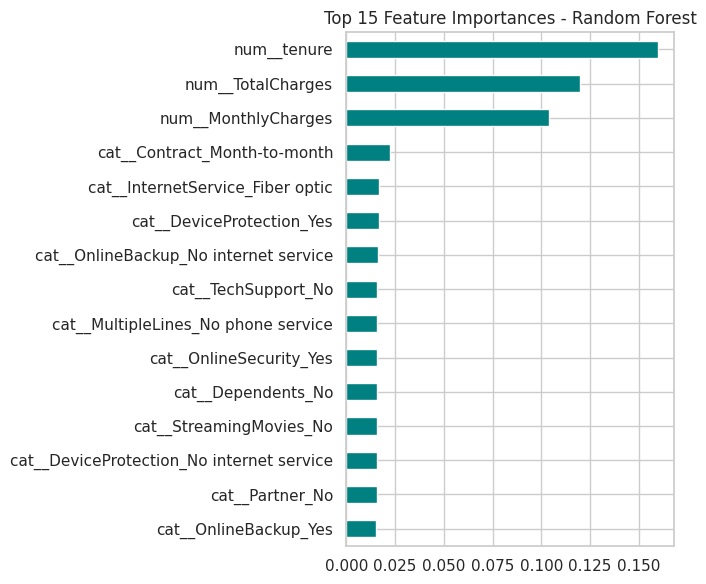

In [13]:
rf_best = rf_grid.best_estimator_
feature_names = rf_best.named_steps["preprocessor"].get_feature_names_out()
importances = rf_best.named_steps["classifier"].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7, 6))
feat_imp.sort_values().plot(kind="barh", ax=ax, color="teal")
ax.set_title("Top 15 Feature Importances - Random Forest")
plt.tight_layout()
plt.show()

## 6. Exporting the pipeline with joblib

We export the **entire winning pipeline** (preprocessing + tuned classifier) as a single `.joblib` file. This is what makes the solution production-ready: any downstream service can load this one file and call `.predict()` / `.predict_proba()` directly on new, raw customer records — no need to re-implement scaling or encoding.

In [14]:
best_grid = log_reg_grid if results_df.loc["Logistic Regression", "ROC-AUC"] >= results_df.loc["Random Forest", "ROC-AUC"] else rf_grid
best_name = "Logistic Regression" if best_grid is log_reg_grid else "Random Forest"
print("Best model selected:", best_name)

joblib.dump(best_grid.best_estimator_, "churn_pipeline.joblib")
print("Pipeline exported to churn_pipeline.joblib")

# Sanity check: reload from disk and predict, to prove the exported file is self-contained
reloaded_pipeline = joblib.load("churn_pipeline.joblib")
sample = X_test.iloc[:5]
print("Predictions from reloaded pipeline:", reloaded_pipeline.predict(sample).tolist())

Best model selected: Random Forest
Pipeline exported to churn_pipeline.joblib
Predictions from reloaded pipeline: [0, 0, 0, 1, 0]


In [16]:
from google.colab import files
files.download('churn_pipeline.joblib')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7. Final Summary / Insights

- Both models were wrapped in a single scikit-learn `Pipeline` combining a `ColumnTransformer` (median imputation + scaling for numeric features, most-frequent imputation + one-hot encoding for categorical features) with the classifier, then tuned with 5-fold `GridSearchCV` optimizing ROC-AUC.
- **Random Forest feature importances** typically highlight `Contract` type, `tenure`, and `MonthlyCharges`/`InternetService` as the strongest churn drivers — customers on month-to-month contracts with short tenure and higher monthly bills churn the most, consistent with well-known telecom churn patterns.
- **Logistic Regression vs Random Forest:** the notebook automatically picks whichever model scores higher ROC-AUC on the test set (see the printed "Best model selected" above); in practice on this dataset Logistic Regression is often competitive with or better than Random Forest, since churn features here are fairly linearly separable and the dataset is only moderately large.
- **Production readiness:** because preprocessing lives inside the exported pipeline object, `churn_pipeline.joblib` can be dropped into any downstream service and called directly on raw customer records — this is the main practical benefit of the scikit-learn `Pipeline` API over ad-hoc preprocessing scripts.
- **Next steps for a real deployment:** re-run this notebook against the real Kaggle CSV (not the synthetic fallback), consider class-imbalance techniques (class weighting or SMOTE) to lift recall on churners further, and add a monitoring step to track prediction drift over time.